# Stage 04 — Exploratory Data Analysis

**Owner:** Pujan Dey (Visualisation & Reporting Lead)

**Objective.** Produce the visual story that (a) answers **RQ3** (descriptive) and **RQ4** (diagnostic correlation) directly, and (b) informs the RQ1 modelling decisions via correlation and multicollinearity checks (VIF).

**Inputs.** Checkpoints from notebook 03.

**Outputs.**
- Figures in `outputs/figures/` used in the slide deck.
- `outputs/tables/rq1_vif.csv`

## 1. Setup and load checkpoints

In [1]:
import sys, json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

from src import config, eda, reporting

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

def _load(name):
    p = config.CHECKPOINT_DIR / name
    return pd.read_parquet(p) if p.exists() else pd.read_csv(p.with_suffix('.csv'))

master = _load("03_master_with_targets.parquet")
X = _load("03_X.parquet")
y_reg = _load("03_y_reg.parquet").iloc[:, 0]
y_cls = _load("03_y_cls.parquet").iloc[:, 0]
print("master:", master.shape, "| X:", X.shape)

master: (8239, 20) | X: (7971, 24)


## 2. RQ3 — Gender composition by ANZSIC division

Mean proportion of women in the overall workforce, per ANZSIC division. The dashed line at 0.5 marks parity — divisions well below it (e.g. Construction, Mining) are where gender imbalance is most entrenched in the private-sector cohort.

21:45:05 | INFO    | src.eda | Saved rq3_women_share_by_division.png


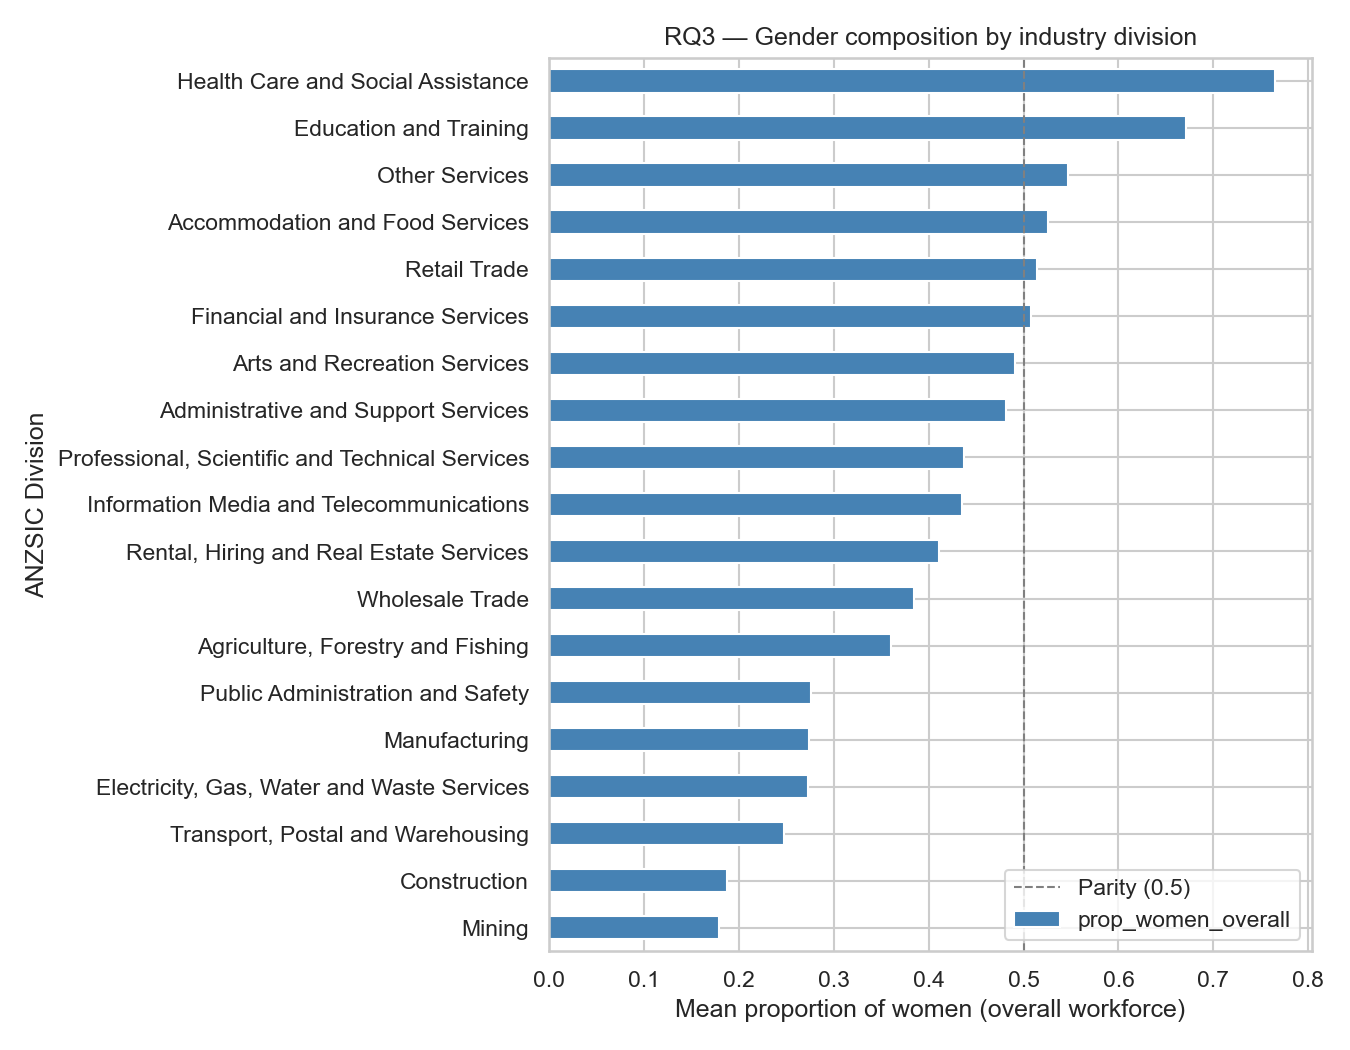

,mean,median,count
anzsic_division,,,
Mining,0.179,0.167,277
Construction,0.188,0.153,445
"Transport, Postal and Warehousing",0.248,0.207,370
"Electricity, Gas, Water and Waste Services",0.273,0.244,98
Manufacturing,0.274,0.237,870
Public Administration and Safety,0.276,0.249,62
"Agriculture, Forestry and Fishing",0.360,0.377,104
Wholesale Trade,0.385,0.333,470
"Rental, Hiring and Real Estate Services",0.411,0.430,115


In [2]:
p = eda.plot_gender_composition_by_division(master)
display(Image(str(p)))

# Table version for the slide appendix
div_table = master.groupby("anzsic_division")["prop_women_overall"].agg(["mean", "median", "count"]).sort_values("mean")
div_table.round(3)

## 3. RQ3 — Gender composition by employer size

21:45:05 | INFO    | src.eda | Saved rq3_women_share_by_size.png


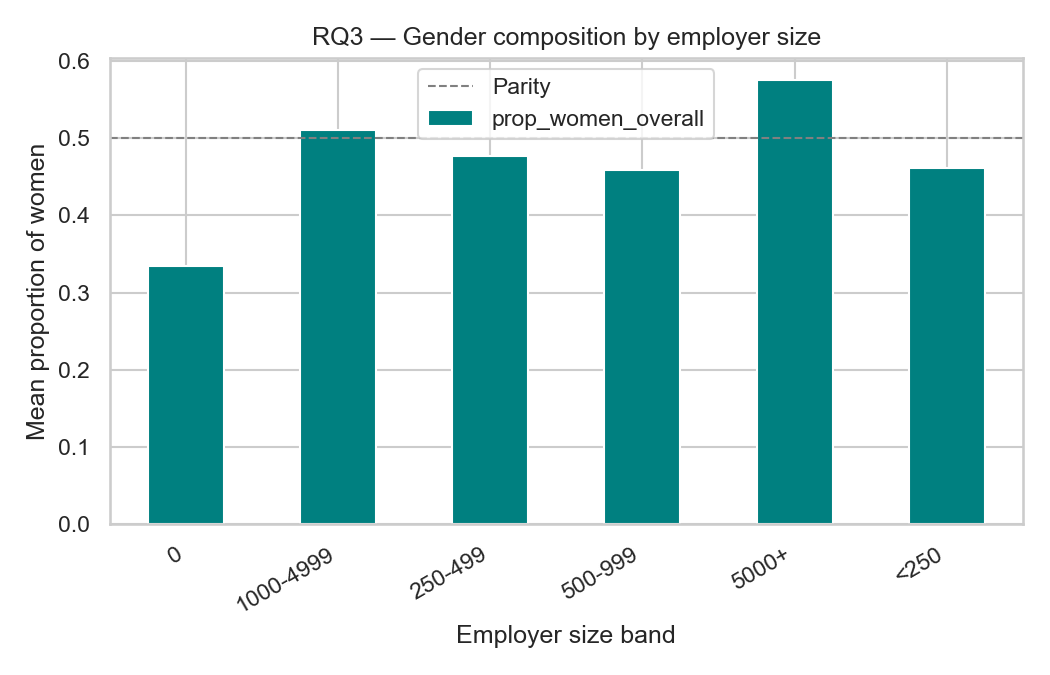

,prop_women_overall,prop_women_mgmt
employer_size,,
0,0.334,0.249
1000-4999,0.510,0.459
250-499,0.477,0.422
500-999,0.458,0.420
5000+,0.575,0.524
<250,0.461,0.400


In [3]:
p = eda.plot_gender_composition_by_size(master)
display(Image(str(p)))

master.groupby("employer_size")[["prop_women_overall", "prop_women_mgmt"]].mean().round(3)

## 4. RQ4 — Policy adoption vs women-in-workforce

Box plots of `prop_women_overall` grouped by each binary policy flag. A visible lift from the 0 box to the 1 box is diagnostic evidence that organisations adopting that policy also employ more women — *association*, not causation.

d:\CDU\Semester3\PRT564_DATA_ANALYTICS_AND_VISUALISATION\project\src\eda.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=flag, y="prop_women_overall", ax=ax, palette="Set2")
d:\CDU\Semester3\PRT564_DATA_ANALYTICS_AND_VISUALISATION\project\src\eda.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=flag, y="prop_women_overall", ax=ax, palette="Set2")
d:\CDU\Semester3\PRT564_DATA_ANALYTICS_AND_VISUALISATION\project\src\eda.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=flag, y="prop_women_overall", 

21:45:06 | INFO    | src.eda | Saved rq4_policy_vs_women.png


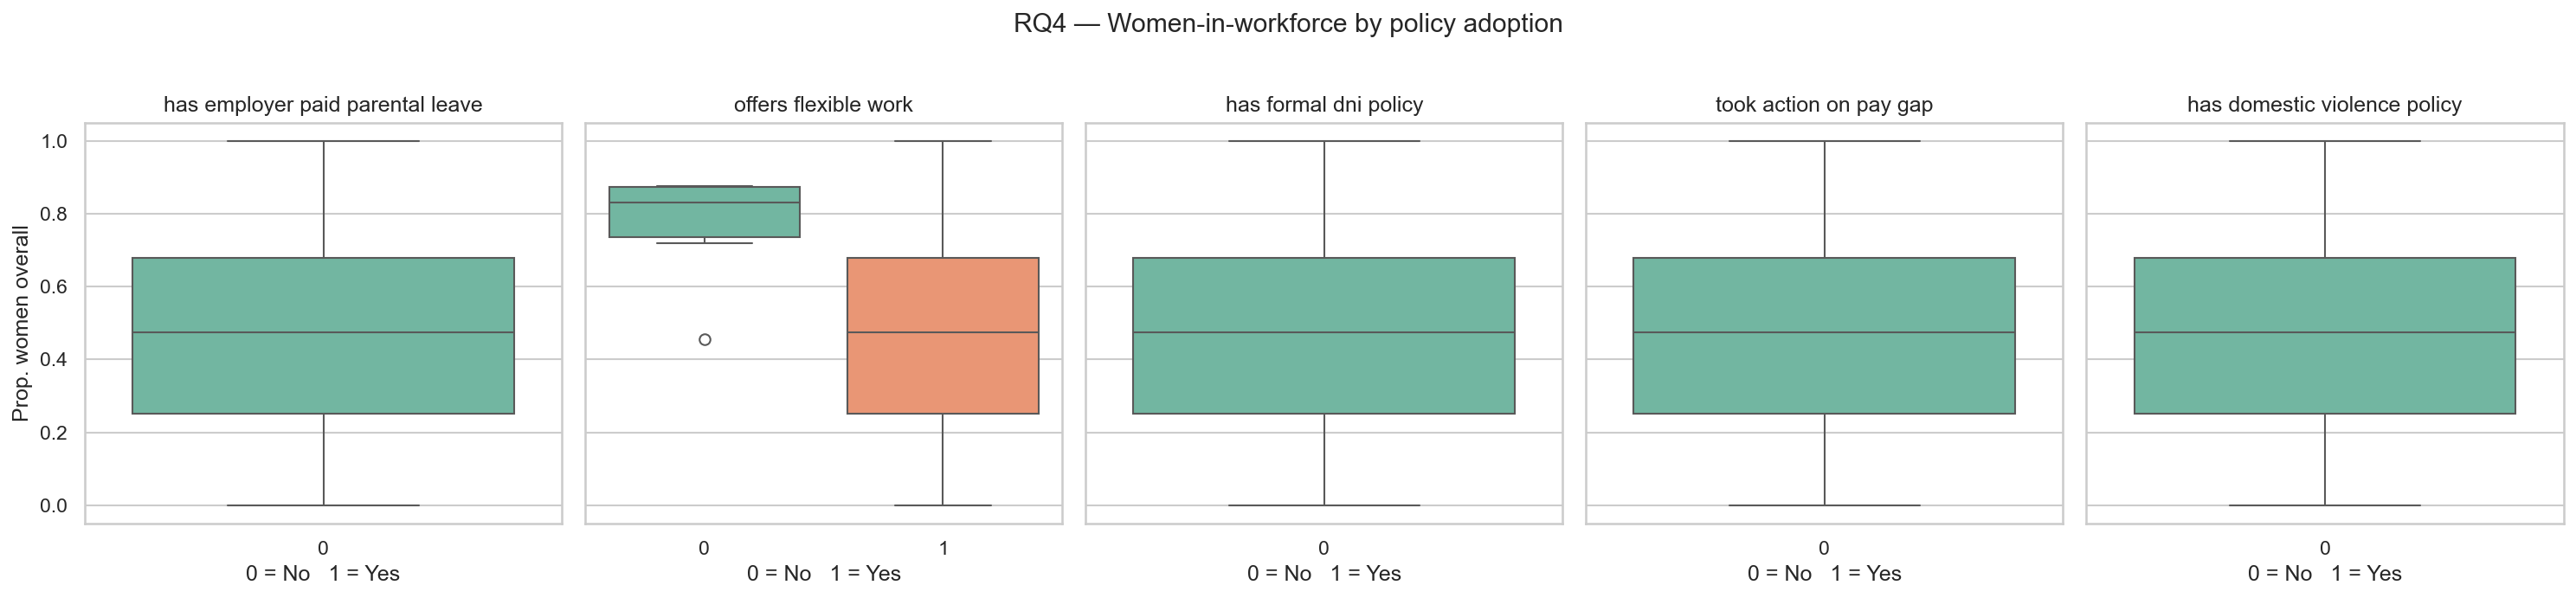

In [4]:
p = eda.plot_policy_vs_workforce_women(master)
display(Image(str(p)))

In [5]:
# Quantify the lift
policy_cols = [c for c in master.columns if c.startswith(("has_", "offers_", "took_"))]
rows = []
for col in policy_cols:
    grp = master.groupby(col)["prop_women_overall"].mean()
    if 0 in grp.index and 1 in grp.index:
        rows.append({"policy": col, "mean_no": grp[0], "mean_yes": grp[1], "lift": grp[1] - grp[0]})
pd.DataFrame(rows).sort_values("lift", ascending=False).round(3)

,policy,mean_no,mean_yes,lift
0,offers_flexible_work,0.763,0.471,-0.292


## 5. Correlation heatmap (RQ4 quantitative view + RQ1 diagnostic)

Top 15 features by |corr| with `prop_women_mgmt`. Any pair with |r| ≥ 0.8 flags a multicollinearity concern for the OLS regression.

21:45:07 | INFO    | src.eda | Saved correlation_heatmap.png


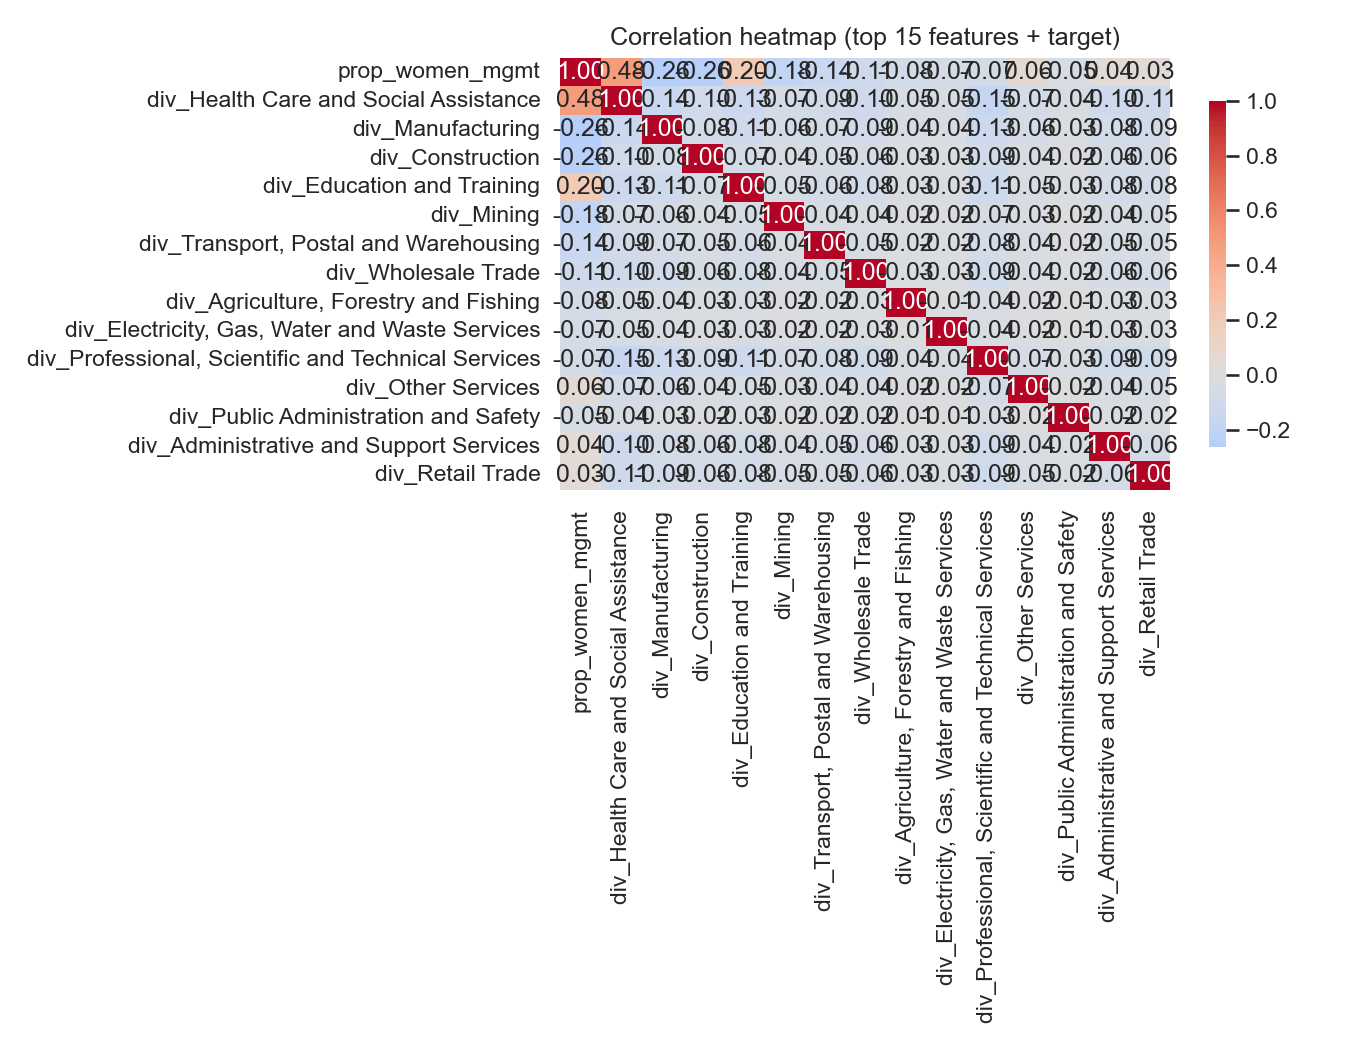

In [6]:
p = eda.plot_correlation_matrix(X, y_reg)
display(Image(str(p)))

## 6. Variance Inflation Factor (VIF) — multicollinearity check

VIF = 1 means the feature is uncorrelated with the others; VIF > 5 warns of collinearity and > 10 is serious. This is an explicit assumption check declared in Assessment 1 §4.2.

In [7]:
vif_df = eda.compute_vif(X)
reporting.write_vif(vif_df)
print("VIF summary (top 20):")
display(vif_df.head(20))
print("\nFeatures with VIF > 5:")
display(vif_df[vif_df["vif"] > 5])

VIF summary (top 20):


,feature,vif
0,div_Health Care and Social Assistance,2.720928
1,"div_Professional, Scientific and Technical Ser...",2.439310
2,div_Manufacturing,2.286341
3,div_Education and Training,2.082506
4,div_Retail Trade,1.794011
5,div_Wholesale Trade,1.746604
6,div_Administrative and Support Services,1.734434
7,div_Construction,1.687820
8,div_Financial and Insurance Services,1.641390
9,"div_Transport, Postal and Warehousing",1.554386



Features with VIF > 5:


,feature,vif


## Summary

- RQ3 answered descriptively — industry and size both move the dial.
- RQ4 answered diagnostically — policy adoption shows non-trivial lifts in women-in-workforce for most flags.
- Correlation heatmap + VIF flagged any variables to watch when we fit the regression next.

**Next:** `05_regression.ipynb` — fit OLS for RQ1.